# PyTorch ResNet50 Full-Resolution Training

Train a ResNet50 regressor on fractal k_min prediction using full images at a single resolution.

**Optimized for RTX 3050 Ti (4GB VRAM)**

In [1]:
from pathlib import Path
import gc
import json
import time
import tracemalloc
from functools import wraps

import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as transforms

try:
    import psutil
except ImportError:
    psutil = None

try:
    from torchinfo import summary as model_summary
except ImportError:
    model_summary = None
    print('torchinfo not found – run: pip install torchinfo')

MEMORY_PROFILE_LOGS = []
ENABLE_MEMORY_PROFILING = True


def _get_rss_memory_mb():
    if psutil is not None:
        return psutil.Process().memory_info().rss / (1024 ** 2)

    try:
        import resource

        rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        return rss / (1024 ** 2) if rss > 10 ** 7 else rss / 1024
    except Exception:
        return float('nan')


def _get_cuda_memory_snapshot():
    if not torch.cuda.is_available():
        return None

    torch.cuda.synchronize()
    return {
        'allocated_mb': torch.cuda.memory_allocated() / (1024 ** 2),
        'reserved_mb': torch.cuda.memory_reserved() / (1024 ** 2),
        'max_allocated_mb': torch.cuda.max_memory_allocated() / (1024 ** 2),
        'max_reserved_mb': torch.cuda.max_memory_reserved() / (1024 ** 2),
    }


def memory_profile(label=None, track_cuda=True):
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            if not ENABLE_MEMORY_PROFILING:
                return func(*args, **kwargs)

            gc.collect()
            rss_before = _get_rss_memory_mb()

            if track_cuda and torch.cuda.is_available():
                torch.cuda.synchronize()
                torch.cuda.reset_peak_memory_stats()
                cuda_before = _get_cuda_memory_snapshot()
            else:
                cuda_before = None

            tracemalloc.start()
            start = time.perf_counter()
            try:
                return func(*args, **kwargs)
            finally:
                if track_cuda and torch.cuda.is_available():
                    torch.cuda.synchronize()

                elapsed_s = time.perf_counter() - start
                _, python_peak_bytes = tracemalloc.get_traced_memory()
                tracemalloc.stop()
                rss_after = _get_rss_memory_mb()
                cuda_after = _get_cuda_memory_snapshot() if track_cuda else None

                record = {
                    'label': label or func.__name__,
                    'elapsed_s': round(float(elapsed_s), 3),
                    'rss_before_mb': round(float(rss_before), 2),
                    'rss_after_mb': round(float(rss_after), 2),
                    'rss_delta_mb': round(float(rss_after - rss_before), 2),
                    'python_peak_mb': round(float(python_peak_bytes / (1024 ** 2)), 2),
                }

                if cuda_before is not None and cuda_after is not None:
                    record.update({
                        'cuda_allocated_before_mb': round(float(cuda_before['allocated_mb']), 2),
                        'cuda_allocated_after_mb': round(float(cuda_after['allocated_mb']), 2),
                        'cuda_allocated_peak_mb': round(float(cuda_after['max_allocated_mb']), 2),
                        'cuda_reserved_before_mb': round(float(cuda_before['reserved_mb']), 2),
                        'cuda_reserved_after_mb': round(float(cuda_after['reserved_mb']), 2),
                        'cuda_reserved_peak_mb': round(float(cuda_after['max_reserved_mb']), 2),
                    })

                MEMORY_PROFILE_LOGS.append(record)

                message = (
                    f"[memory] {record['label']}: "
                    f"RSS {record['rss_before_mb']:.2f} -> {record['rss_after_mb']:.2f} MB "
                    f"(Δ {record['rss_delta_mb']:+.2f} MB), "
                    f"Python peak {record['python_peak_mb']:.2f} MB, "
                    f"time {record['elapsed_s']:.2f}s"
                )
                if 'cuda_allocated_peak_mb' in record:
                    message += (
                        f", CUDA alloc peak {record['cuda_allocated_peak_mb']:.2f} MB"
                        f", CUDA reserved peak {record['cuda_reserved_peak_mb']:.2f} MB"
                    )
                print(message)

        return wrapper

    return decorator


def summarize_memory_profiles(sort_key='elapsed_s'):
    if not MEMORY_PROFILE_LOGS:
        print('No memory profile data collected yet.')
        return []

    summary = sorted(
        MEMORY_PROFILE_LOGS,
        key=lambda item: item.get(sort_key, 0.0),
        reverse=True,
    )
    print('\nMemory profile summary:')
    for item in summary:
        line = (
            f"  - {item['label']}: "
            f"time={item['elapsed_s']:.2f}s | "
            f"ΔRSS={item['rss_delta_mb']:+.2f} MB | "
            f"py_peak={item['python_peak_mb']:.2f} MB"
        )
        if 'cuda_allocated_peak_mb' in item:
            line += f" | cuda_peak={item['cuda_allocated_peak_mb']:.2f} MB"
        print(line)
    return summary


# Setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Configuration
DATASET_DIR = Path('../../data/kmin_auto_batch')
OUTPUT_DIR = Path('../../outputs/pytorch_resnet')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESOLUTIONS = [256, 512]
PATCH_SIZE = 128
MAX_PATCHES_PER_IMAGE = 2
BATCH_SIZE = 4
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 30
EARLY_STOP_PATIENCE = 5
SEED = 42

USE_PRETRAINED = False

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f'\nConfig:\n  Batch: {BATCH_SIZE}\n  Patches: {MAX_PATCHES_PER_IMAGE}\n  Patch size: {PATCH_SIZE}x{PATCH_SIZE}\n  Dataset: {DATASET_DIR}')
print(f'  Memory profiling: {ENABLE_MEMORY_PROFILING}')
print(f'  Pretrained: {USE_PRETRAINED}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB

Config:
  Batch: 4
  Patches: 2
  Patch size: 128x128
  Dataset: ../data/kmin_auto_batch
  Memory profiling: True
  Pretrained: False


In [2]:
# Override config: single full resolution, larger batches, no patch extraction
SINGLE_RESOLUTION = 256
RESOLUTIONS = [SINGLE_RESOLUTION]
BATCH_SIZE = 4
PATCH_SIZE = SINGLE_RESOLUTION
MAX_PATCHES_PER_IMAGE = None

print('\nOverride config:')
print(f'  Resolution: {SINGLE_RESOLUTION}x{SINGLE_RESOLUTION}')
print(f'  Batch size: {BATCH_SIZE}')
print('  Mode: full images (no patches)')


Override config:
  Resolution: 256x256
  Batch size: 4
  Mode: full images (no patches)


In [3]:
class HDF5PatchDataset(Dataset):
    """PyTorch Dataset for full-resolution HDF5 images (keeps name for compatibility)."""

    def __init__(self, index_records, patch_size=None, max_patches=None, augment=False):
        self.records = index_records  # (file_path, resolution, image_idx, k_min)
        self.augment = augment

        if augment:
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
            ])
        else:
            self.transform = None

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        file_path, resolution, image_idx, k_min = self.records[idx]

        group_key = f"{resolution}x{resolution}"
        with h5py.File(file_path, 'r') as f:
            img = f[f"{group_key}/images"][image_idx]

        image = img.astype(np.float32) / 255.0
        image = np.stack([image, image, image], axis=0)  # (3, H, W)

        image = torch.from_numpy(image)
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(k_min, dtype=torch.float32)
        return image, label

## Data Loading

In [4]:
# Discover and index HDF5 files
h5_files = sorted(DATASET_DIR.glob('*.h5'))
print(f'Found {len(h5_files)} HDF5 files')

records = []
for fpath in h5_files:
    try:
        with h5py.File(fpath, 'r') as f:
            for res in RESOLUTIONS:
                group_key = f'{res}x{res}'
                if group_key not in f:
                    continue
                n_images = f[group_key].attrs.get('num_images', 0)
                k_min_arr = f[f'{group_key}/parameters/k_min'][:]
                for idx in range(int(n_images)):
                    records.append((str(fpath), res, idx, float(k_min_arr[idx])))
    except Exception as e:
        print(f'Warning: {fpath}: {e}')

print(f'Total indexed samples: {len(records)}')

# Convert to structured array for easy indexing
records_arr = np.array(
    records,
    dtype=[('file_path', 'U256'), ('resolution', np.int32),
            ('image_idx', np.int32), ('k_min', np.float32)]
)

# Stratified split
idx = np.arange(len(records_arr))
k_min_vals = records_arr['k_min']
bins = np.linspace(k_min_vals.min(), k_min_vals.max() + 1e-6, 32 + 1)
strata = np.digitize(k_min_vals, bins)

idx_train, idx_temp = train_test_split(
    idx, test_size=0.30, stratify=strata, random_state=SEED
)
strata_temp = strata[idx_temp]
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=strata_temp, random_state=SEED
)

train_records = records_arr[idx_train].tolist()
val_records = records_arr[idx_val].tolist()
test_records = records_arr[idx_test].tolist()

print(f'\nSplit:\n  Train: {len(train_records)}\n  Val: {len(val_records)}\n  Test: {len(test_records)}')

# Create datasets (dataset is pre-balanced, no weighted sampler needed)
train_dataset = HDF5PatchDataset(train_records, patch_size=PATCH_SIZE, max_patches=MAX_PATCHES_PER_IMAGE, augment=True)
val_dataset = HDF5PatchDataset(val_records, patch_size=PATCH_SIZE, max_patches=MAX_PATCHES_PER_IMAGE, augment=False)
test_dataset = HDF5PatchDataset(test_records, patch_size=PATCH_SIZE, max_patches=MAX_PATCHES_PER_IMAGE, augment=False)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f'\nDataLoaders created')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val batches: {len(val_loader)}')
print(f'  Test batches: {len(test_loader)}')

Found 32 HDF5 files
Total indexed samples: 32000

Split:
  Train: 22400
  Val: 4800
  Test: 4800

DataLoaders created
  Train batches: 5600
  Val batches: 1200
  Test batches: 1200


## Build Model

In [5]:
class ResNet50Regressor(nn.Module):
    """ResNet50 for regression (all layers trainable)."""

    def __init__(self, pretrained=False):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.backbone(x)


def clear_cuda_state():
    for var_name in ['model', 'optimizer', 'scheduler', 'loss_fn']:
        if var_name in globals():
            del globals()[var_name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required for this notebook run, but no CUDA device is available.')

DEVICE = torch.device('cuda')
clear_cuda_state()

try:
    model = ResNet50Regressor(pretrained=USE_PRETRAINED).to(DEVICE)
except torch.cuda.OutOfMemoryError:
    print('\nCUDA OOM while moving model to GPU. Clearing cache and retrying...')
    clear_cuda_state()
    try:
        model = ResNet50Regressor(pretrained=USE_PRETRAINED).to(DEVICE)
    except torch.cuda.OutOfMemoryError as e:
        raise RuntimeError(
            'CUDA OOM during model initialization. CUDA-only mode is enforced. '
            'Restart kernel to clear stale GPU memory and/or reduce BATCH_SIZE before rerunning.'
        ) from e

print(f'Active device for model: {DEVICE}')

# Model summary
if model_summary is not None:
    model_summary(
        model,
        input_size=(BATCH_SIZE, 3, PATCH_SIZE, PATCH_SIZE),
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        row_settings=['var_names'],
        device=DEVICE,
    )
else:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('Model: ResNet50 Regressor')
    print(f'  Total params: {total_params:,}')
    print(f'  Trainable params: {trainable_params:,}')
    print('  (install torchinfo for a full layer-by-layer summary)')

# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.SmoothL1Loss(beta=1.0)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

print('\n✓ Model, optimizer, scheduler ready')

Active device for model: cuda

✓ Model, optimizer, scheduler ready


## Training Loop

In [6]:
@memory_profile('train_epoch')
def train_epoch(model, loader, optimizer, loss_fn, device):
    """Train one epoch."""
    model.train()
    total_loss = 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


@memory_profile('eval_epoch')
def eval_epoch(model, loader, loss_fn, device):
    """Evaluate one epoch."""
    model.eval()
    total_loss = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating', leave=False):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predictions.extend(outputs.cpu().numpy().flatten())
            targets.extend(labels.cpu().numpy().flatten())

    loss = total_loss / len(loader.dataset)
    mae = np.mean(np.abs(np.array(predictions) - np.array(targets)))
    rmse = np.sqrt(np.mean((np.array(predictions) - np.array(targets)) ** 2))

    return float(loss), float(mae), float(rmse), np.array(predictions), np.array(targets)


def get_kernel_stats(model):
    conv1 = model.backbone.conv1.weight.detach()
    conv_last = model.backbone.layer4[-1].conv3.weight.detach()
    return {
        'conv1_l2': float(torch.norm(conv1).item()),
        'conv_last_l2': float(torch.norm(conv_last).item()),
        'conv1': conv1.clone(),
        'conv_last': conv_last.clone(),
    }


# Training
print(f'\nStarting training for {EPOCHS} epochs...\n')

history = {
    'train_loss': [],
    'val_loss': [],
    'val_mae': [],
    'val_rmse': [],
    'conv1_l2': [],
    'conv_last_l2': [],
    'conv1_delta': [],
    'conv_last_delta': [],
}
best_val_loss = float('inf')
patience_counter = 0

prev_stats = get_kernel_stats(model)

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_mae, val_rmse, val_preds, val_targets = eval_epoch(model, val_loader, loss_fn, DEVICE)

    current_stats = get_kernel_stats(model)
    conv1_delta = float((current_stats['conv1'] - prev_stats['conv1']).abs().mean().item())
    conv_last_delta = float((current_stats['conv_last'] - prev_stats['conv_last']).abs().mean().item())

    history['train_loss'].append(float(train_loss))
    history['val_loss'].append(float(val_loss))
    history['val_mae'].append(float(val_mae))
    history['val_rmse'].append(float(val_rmse))
    history['conv1_l2'].append(current_stats['conv1_l2'])
    history['conv_last_l2'].append(current_stats['conv_last_l2'])
    history['conv1_delta'].append(conv1_delta)
    history['conv_last_delta'].append(conv_last_delta)

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f} | "
        f"Δconv1: {conv1_delta:.6f} | ΔconvL: {conv_last_delta:.6f}"
    )

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

    prev_stats = current_stats

print('\n✓ Training complete')

# Save history
history_serializable = {
    key: [float(v) for v in values]
    for key, values in history.items()
}
with open(OUTPUT_DIR / 'history.json', 'w') as f:
    json.dump(history_serializable, f, indent=2)


Starting training for 30 epochs...



[memory] train_epoch: RSS 1483.38 -> 1752.04 MB (Δ +268.66 MB), Python peak 1.78 MB, time 337.52s, CUDA alloc peak 790.79 MB, CUDA reserved peak 832.00 MB


[memory] eval_epoch: RSS 1752.04 -> 1752.19 MB (Δ +0.15 MB), Python peak 0.66 MB, time 20.24s, CUDA alloc peak 451.01 MB, CUDA reserved peak 832.00 MB
Epoch 1/30 | Train Loss: 6.8849 | Val Loss: 2.7653 | MAE: 3.2122 | RMSE: 6.2942 | Δconv1: 0.003418 | ΔconvL: 0.004659


[memory] train_epoch: RSS 1763.54 -> 1764.36 MB (Δ +0.82 MB), Python peak 1.66 MB, time 338.39s, CUDA alloc peak 793.29 MB, CUDA reserved peak 832.00 MB


[memory] eval_epoch: RSS 1764.36 -> 1764.77 MB (Δ +0.41 MB), Python peak 0.65 MB, time 20.53s, CUDA alloc peak 451.26 MB, CUDA reserved peak 832.00 MB
Epoch 2/30 | Train Loss: 3.6569 | Val Loss: 1.6602 | MAE: 2.0749 | RMSE: 3.5332 | Δconv1: 0.003318 | ΔconvL: 0.003795


...

[memory] eval_epoch: RSS 1770.27 -> 1770.33 MB (Δ +0.07 MB), Python peak 0.64 MB, time 20.07s, CUDA alloc peak 451.26 MB, CUDA reserved peak 832.00 MB
Epoch 7/30 | Train Loss: 3.4364 | Val Loss: 1.0597 | MAE: 1.4803 | RMSE: 2.0677 | Δconv1: 0.003799 | ΔconvL: 0.004099


[memory] train_epoch: RSS 1770.33 -> 1770.95 MB (Δ +0.61 MB), Python peak 1.62 MB, time 338.41s, CUDA alloc peak 793.29 MB, CUDA reserved peak 832.00 MB


[memory] eval_epoch: RSS 1770.95 -> 1770.95 MB (Δ +0.01 MB), Python peak 0.66 MB, time 20.48s, CUDA alloc peak 451.26 MB, CUDA reserved peak 832.00 MB
Epoch 8/30 | Train Loss: 3.4002 | Val Loss: 3.6092 | MAE: 4.0490 | RMSE: 13.9475 | Δconv1: 0.004189 | ΔconvL: 0.004806


[memory] train_epoch: RSS 1770.95 -> 1771.57 MB (Δ +0.62 MB), Python peak 1.64 MB, time 337.77s, CUDA alloc peak 793.29 MB, CUDA reserved peak 832.00 MB


[memory] eval_epoch: RSS 1771.57 -> 1771.58 MB (Δ +0.01 MB), Python peak 0.65 MB, time 20.65s, CUDA alloc peak 451.26 MB, CUDA reserved peak 832.00 MB
Epoch 9/30 | Train Loss: 3.4165 | Val Loss: 1.0377 | MAE: 1.4689 | RMSE: 3.3040 | Δconv1: 0.002235 | ΔconvL: 0.002877

Early stopping at epoch 9

✓ Training complete


## Evaluation

In [7]:
# Load best model
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model.pth'))

# Evaluate on test set
print('Evaluating on test set...')
test_loss, test_mae, test_rmse, test_preds, test_targets = eval_epoch(model, test_loader, loss_fn, DEVICE)

test_metrics = {
    'loss': float(test_loss),
    'mae': float(test_mae),
    'rmse': float(test_rmse),
}

print(f'\nTest Metrics:')
for k, v in test_metrics.items():
    print(f'  {k}: {v:.4f}')

with open(OUTPUT_DIR / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)

Evaluating on test set...


[memory] eval_epoch: RSS 1772.40 -> 1772.28 MB (Δ -0.12 MB), Python peak 0.67 MB, time 20.58s, CUDA alloc peak 455.29 MB, CUDA reserved peak 832.00 MB

Test Metrics:
  loss: 0.6537
  mae: 1.0355
  rmse: 1.3357


## Visualization

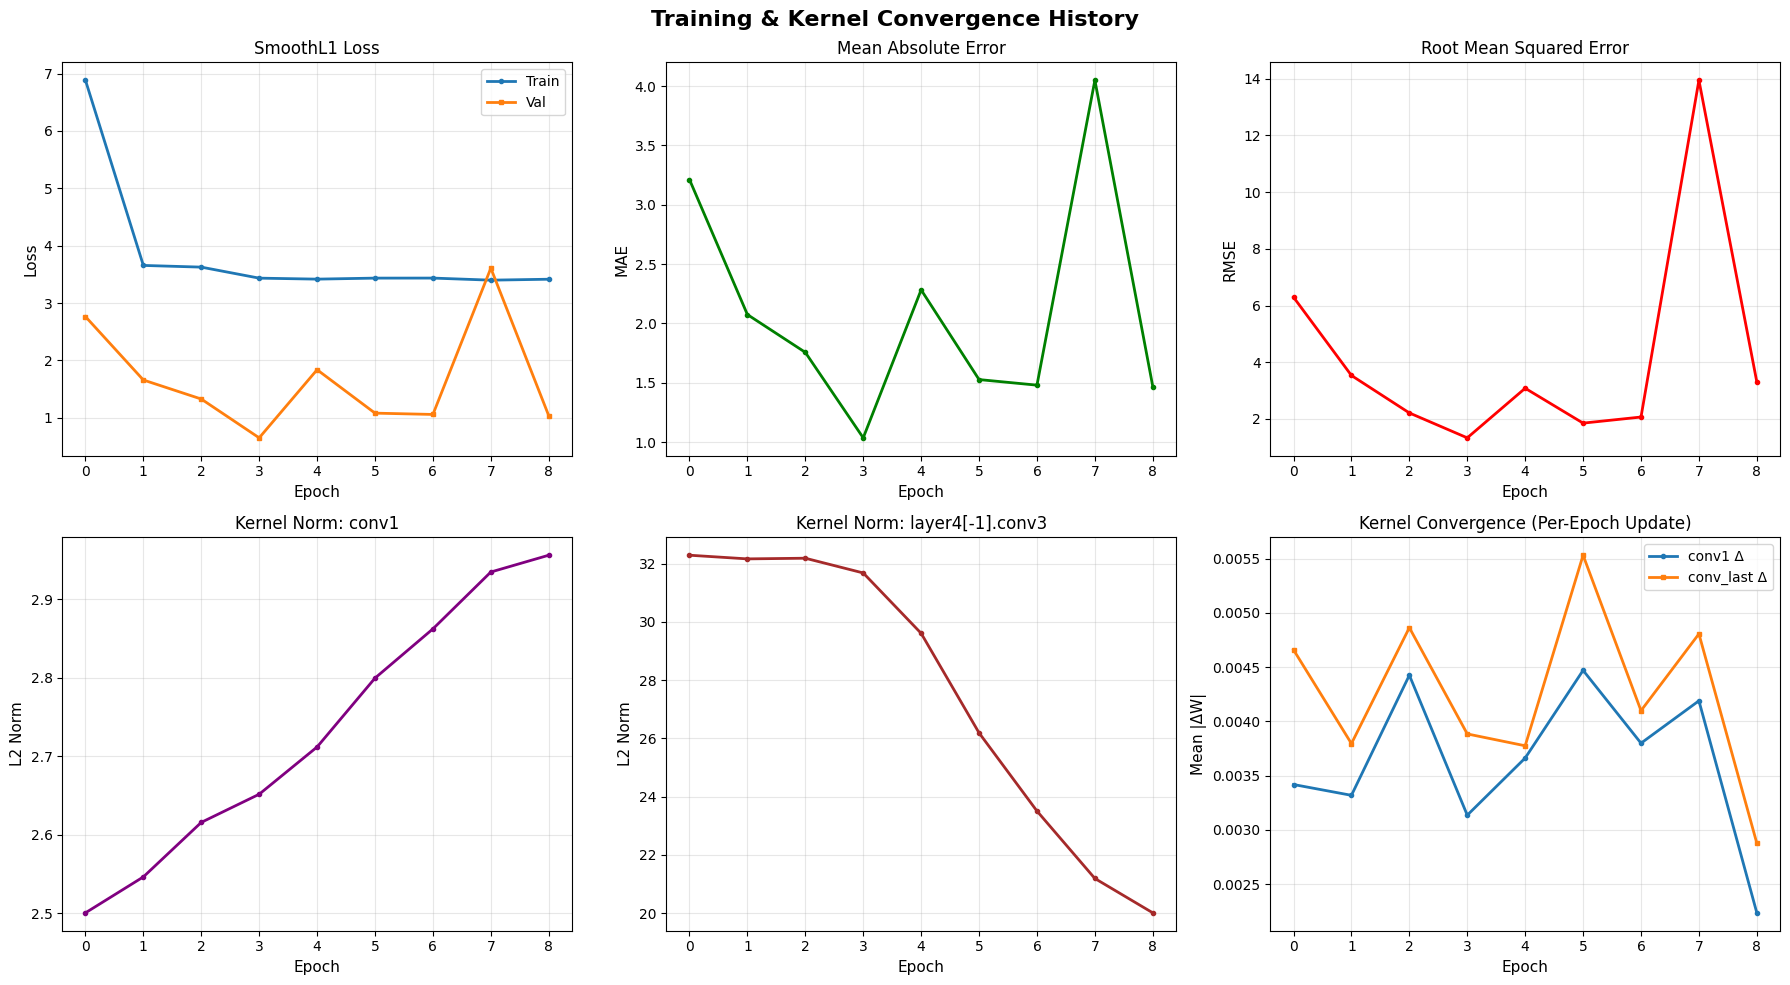

✓ Curves saved


In [8]:
# Plot training + kernel convergence curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training & Kernel Convergence History', fontsize=16, fontweight='bold')

# Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train', linewidth=2, marker='o', markersize=3)
ax.plot(history['val_loss'], label='Val', linewidth=2, marker='s', markersize=3)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('SmoothL1 Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# MAE
ax = axes[0, 1]
ax.plot(history['val_mae'], label='Val MAE', linewidth=2, marker='o', markersize=3, color='green')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
ax.set_title('Mean Absolute Error')
ax.grid(True, alpha=0.3)

# RMSE
ax = axes[0, 2]
ax.plot(history['val_rmse'], label='Val RMSE', linewidth=2, marker='o', markersize=3, color='red')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('RMSE', fontsize=11)
ax.set_title('Root Mean Squared Error')
ax.grid(True, alpha=0.3)

# Conv1 L2 norm
ax = axes[1, 0]
ax.plot(history['conv1_l2'], linewidth=2, marker='o', markersize=3, color='purple')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('L2 Norm', fontsize=11)
ax.set_title('Kernel Norm: conv1')
ax.grid(True, alpha=0.3)

# Last conv L2 norm
ax = axes[1, 1]
ax.plot(history['conv_last_l2'], linewidth=2, marker='o', markersize=3, color='brown')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('L2 Norm', fontsize=11)
ax.set_title('Kernel Norm: layer4[-1].conv3')
ax.grid(True, alpha=0.3)

# Kernel update deltas
ax = axes[1, 2]
ax.plot(history['conv1_delta'], label='conv1 Δ', linewidth=2, marker='o', markersize=3)
ax.plot(history['conv_last_delta'], label='conv_last Δ', linewidth=2, marker='s', markersize=3)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Mean |ΔW|', fontsize=11)
ax.set_title('Kernel Convergence (Per-Epoch Update)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_kernel_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Curves saved')

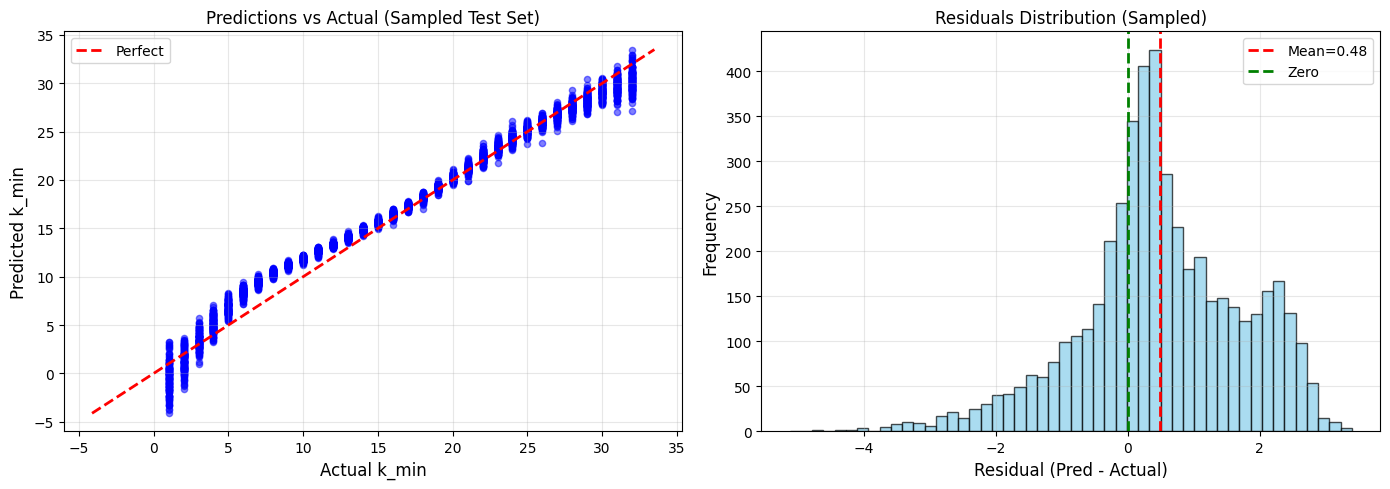


Test Set Stats (streaming over 4,800 samples):
  MAE: 1.0355
  RMSE: 1.3357
  Residual mean: 0.4839
  Residual std: 1.2450
  Plot points kept: 4,800 | Grad-CAM samples kept: 32


In [9]:
# Memory-safe test-set inference (streaming + sampling)
model.eval()

max_plot_points = 120_000
max_gradcam_samples = 32
rng = np.random.default_rng(42)

plot_preds = []
plot_targets = []
gradcam_samples = []

n_seen = 0
sum_abs_error = 0.0
sum_sq_error = 0.0
sum_error = 0.0
sum_error2 = 0.0

cm_round = np.zeros((32, 32), dtype=np.int64)
cm_bins = np.zeros((8, 8), dtype=np.int64)
bin_edges = np.linspace(1, 33, 9)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels_np = labels.numpy().astype(np.float32)
        preds_np = model(images).detach().cpu().numpy().reshape(-1).astype(np.float32)

        errors = preds_np - labels_np
        batch_size = labels_np.shape[0]

        n_seen += batch_size
        sum_abs_error += np.abs(errors).sum()
        sum_sq_error += np.square(errors).sum()
        sum_error += errors.sum()
        sum_error2 += np.square(errors).sum()

        true_rounded = np.clip(np.rint(labels_np), 1, 32).astype(np.int32) - 1
        pred_rounded = np.clip(np.rint(preds_np), 1, 32).astype(np.int32) - 1
        np.add.at(cm_round, (true_rounded, pred_rounded), 1)

        true_bins = np.digitize(labels_np, bin_edges[1:-1], right=False)
        pred_bins = np.digitize(preds_np, bin_edges[1:-1], right=False)
        np.add.at(cm_bins, (true_bins, pred_bins), 1)

        if len(plot_preds) < max_plot_points:
            remaining = max_plot_points - len(plot_preds)
            if batch_size <= remaining:
                keep_idx = np.arange(batch_size)
            else:
                keep_idx = rng.choice(batch_size, size=remaining, replace=False)

            plot_preds.extend(preds_np[keep_idx].tolist())
            plot_targets.extend(labels_np[keep_idx].tolist())

        if len(gradcam_samples) < max_gradcam_samples:
            remaining = max_gradcam_samples - len(gradcam_samples)
            take = min(remaining, batch_size)
            sample_idx = np.linspace(0, batch_size - 1, take, dtype=int) if take < batch_size else np.arange(batch_size)
            for idx in sample_idx:
                gradcam_samples.append((images[idx].detach().cpu().numpy(), float(labels_np[idx])))

        del images

plot_preds = np.asarray(plot_preds, dtype=np.float32)
plot_targets = np.asarray(plot_targets, dtype=np.float32)
plot_residuals = plot_preds - plot_targets

mae = sum_abs_error / max(n_seen, 1)
rmse = np.sqrt(sum_sq_error / max(n_seen, 1))
residual_mean = sum_error / max(n_seen, 1)
residual_var = max((sum_error2 / max(n_seen, 1)) - residual_mean**2, 0.0)
residual_std = np.sqrt(residual_var)

# Predictions vs actual (sampled points for readability)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(plot_targets, plot_preds, alpha=0.5, s=20, color='blue')
lims = [min(plot_targets.min(), plot_preds.min()), max(plot_targets.max(), plot_preds.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
ax.set_xlabel('Actual k_min', fontsize=12)
ax.set_ylabel('Predicted k_min', fontsize=12)
ax.set_title('Predictions vs Actual (Sampled Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(plot_residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax.axvline(plot_residuals.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean={plot_residuals.mean():.2f}')
ax.axvline(0, color='g', linestyle='--', linewidth=2, label='Zero')
ax.set_xlabel('Residual (Pred - Actual)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Residuals Distribution (Sampled)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTest Set Stats (streaming over {n_seen:,} samples):')
print(f'  MAE: {mae:.4f}')
print(f'  RMSE: {rmse:.4f}')
print(f'  Residual mean: {residual_mean:.4f}')
print(f'  Residual std: {residual_std:.4f}')
print(f'  Plot points kept: {len(plot_preds):,} | Grad-CAM samples kept: {len(gradcam_samples):,}')

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Confusion Matrices (Binned and Rounded k_min)

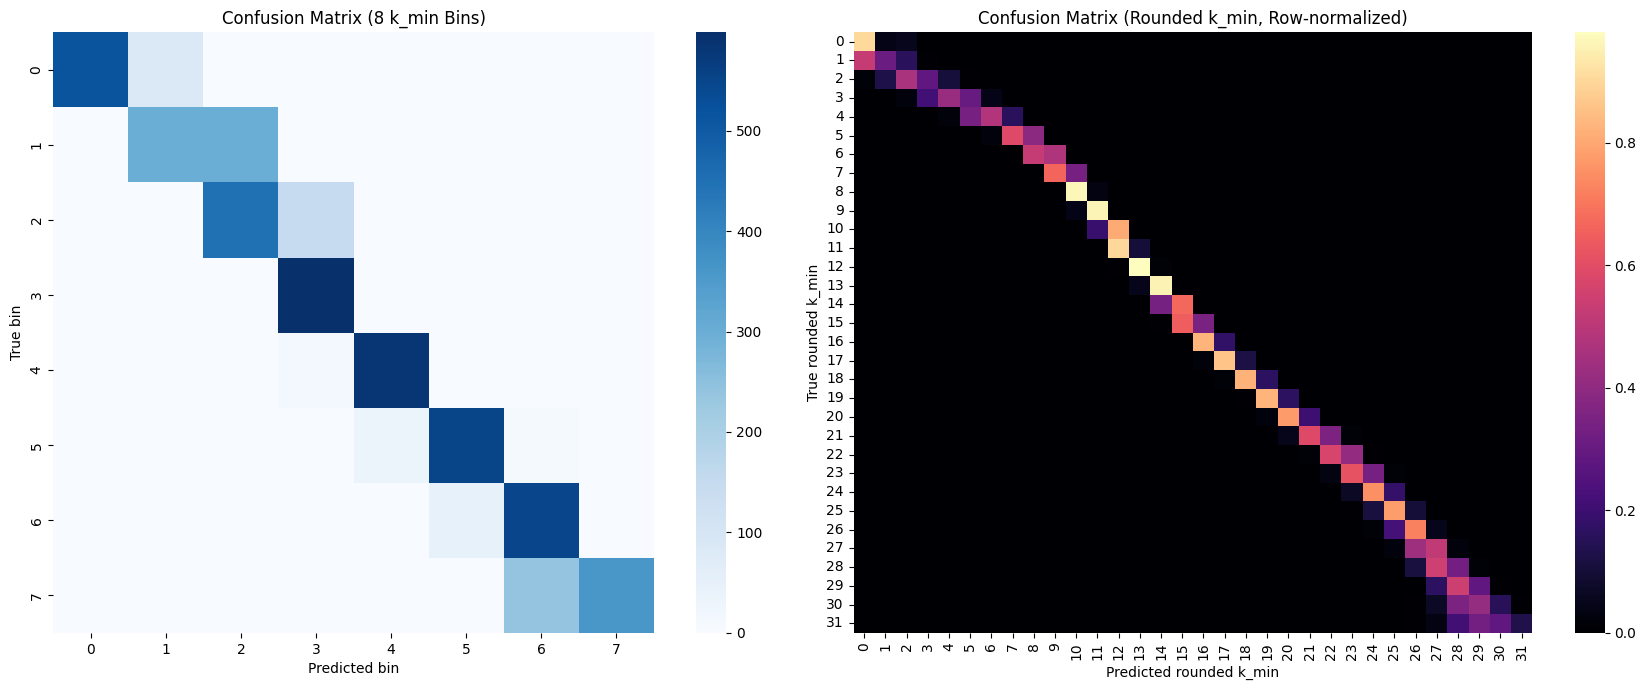

✓ Confusion matrices saved


In [10]:
# Confusion-matrix diagnostics from streaming accumulators
if 'cm_round' not in globals() or 'cm_bins' not in globals():
    raise RuntimeError('Run the previous test-set inference cell first.')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm_bins,
    ax=axes[0],
    cmap='Blues',
    cbar=True,
    square=True,
)
axes[0].set_title('Confusion Matrix (8 k_min Bins)')
axes[0].set_xlabel('Predicted bin')
axes[0].set_ylabel('True bin')

# Normalize rounded confusion by row for readability
cm_round_norm = cm_round.astype(np.float32)
row_sums = cm_round_norm.sum(axis=1, keepdims=True) + 1e-8
cm_round_norm = cm_round_norm / row_sums

sns.heatmap(
    cm_round_norm,
    ax=axes[1],
    cmap='magma',
    cbar=True,
)
axes[1].set_title('Confusion Matrix (Rounded k_min, Row-normalized)')
axes[1].set_xlabel('Predicted rounded k_min')
axes[1].set_ylabel('True rounded k_min')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Confusion matrices saved')

## Grad-CAM Analysis (ResNet50 layer4)

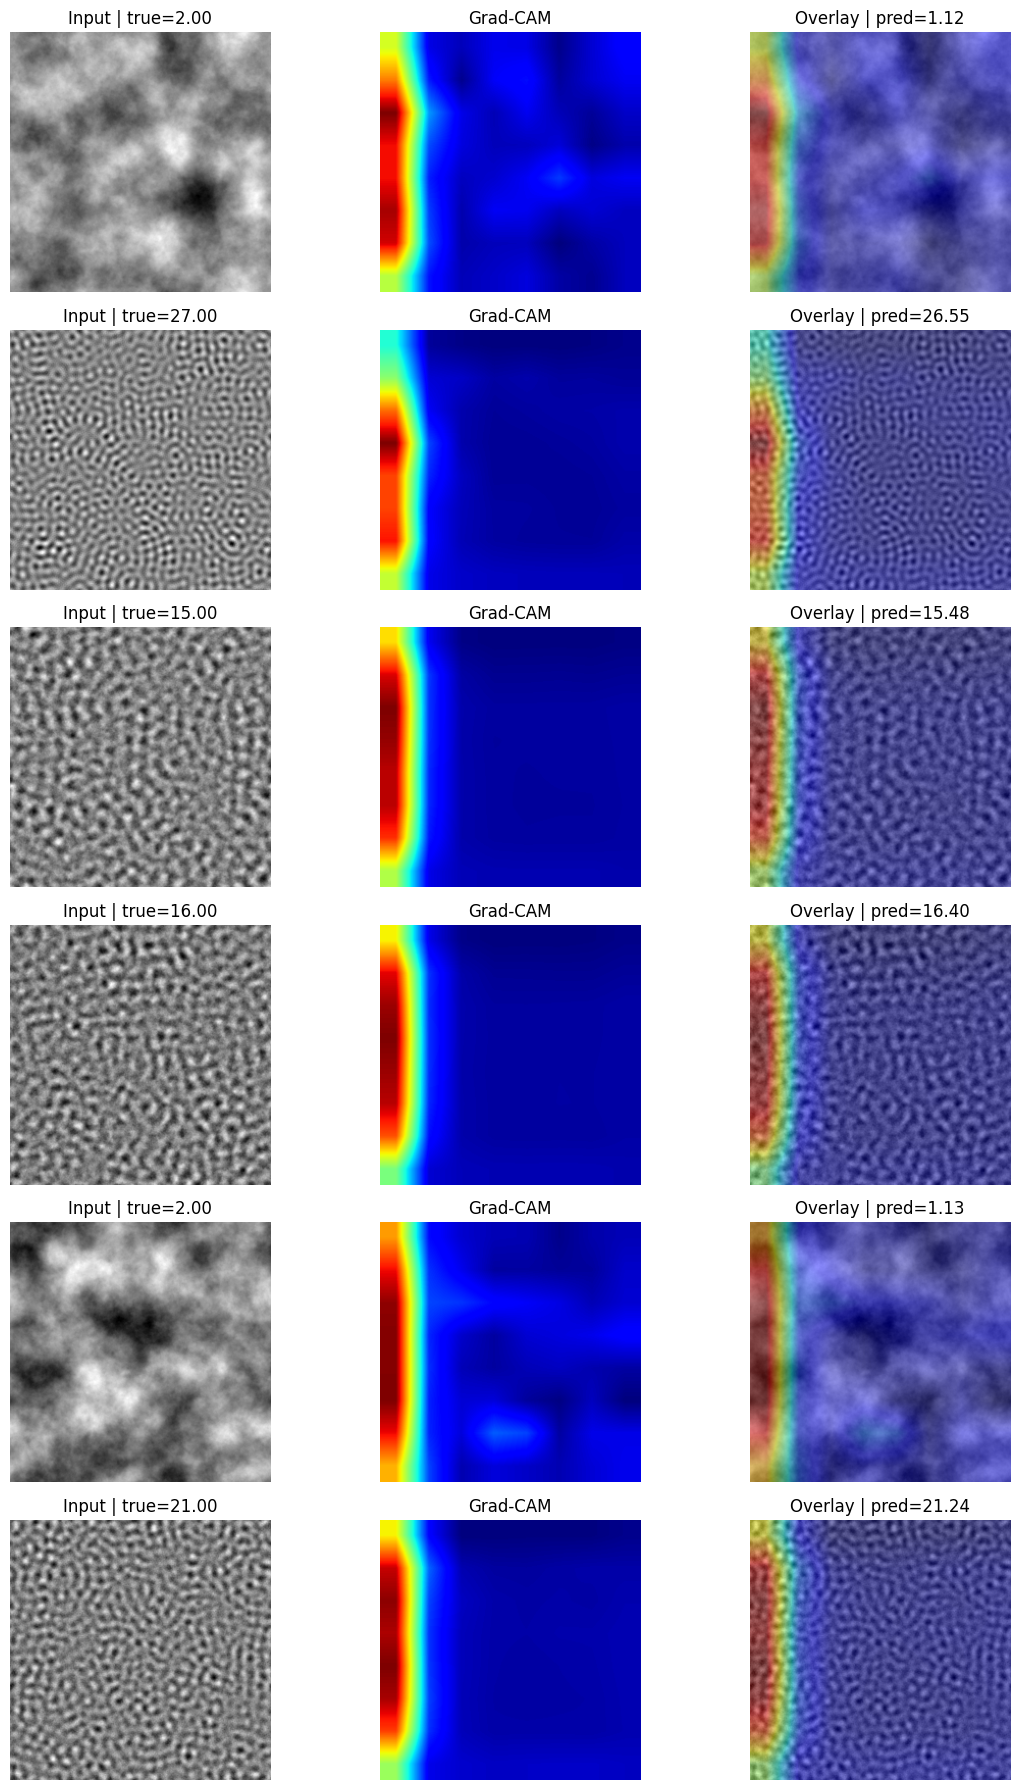

✓ Grad-CAM examples saved


In [11]:
def compute_gradcam(model, input_tensor, target_layer):
    activations = []
    gradients = []

    def forward_hook(module, inp, out):
        activations.append(out.detach())

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    model.eval()
    output = model(input_tensor)
    score = output[:, 0].sum()

    model.zero_grad(set_to_none=True)
    score.backward()

    acts = activations[0]
    grads = gradients[0]

    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)
    cam = torch.nn.functional.interpolate(
        cam,
        size=(input_tensor.shape[2], input_tensor.shape[3]),
        mode='bilinear',
        align_corners=False,
    )
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    h1.remove()
    h2.remove()
    return cam, float(output.detach().cpu().numpy().squeeze())


if 'gradcam_samples' not in globals() or len(gradcam_samples) == 0:
    raise RuntimeError('Run the previous test-set inference cell first to collect Grad-CAM samples.')

# Visualize Grad-CAM for a few sampled test examples
target_layer = model.backbone.layer4[-1].conv3
num_examples = min(6, len(gradcam_samples))
example_idx = np.linspace(0, len(gradcam_samples) - 1, num_examples, dtype=int)

fig, axes = plt.subplots(num_examples, 3, figsize=(12, 3 * num_examples))
if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(example_idx):
    image_np, target_val = gradcam_samples[idx]  # (3,H,W), scalar
    image_tensor = torch.tensor(image_np[None, ...], dtype=torch.float32, device=DEVICE)

    cam, pred_val = compute_gradcam(model, image_tensor, target_layer)
    image_hwc = np.transpose(image_np, (1, 2, 0))
    image_gray = image_hwc.mean(axis=2)

    axes[row, 0].imshow(image_gray, cmap='gray')
    axes[row, 0].set_title(f'Input | true={target_val:.2f}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cam, cmap='jet')
    axes[row, 1].set_title('Grad-CAM')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(image_gray, cmap='gray')
    axes[row, 2].imshow(cam, cmap='jet', alpha=0.45)
    axes[row, 2].set_title(f'Overlay | pred={pred_val:.2f}')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradcam_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Grad-CAM examples saved')

In [12]:
profile_summary = summarize_memory_profiles()

if profile_summary:
    with open(OUTPUT_DIR / 'memory_profiles.json', 'w') as f:
        json.dump(profile_summary, f, indent=2)
    print(f"\n✓ Saved memory profiles to {OUTPUT_DIR / 'memory_profiles.json'}")


Memory profile summary:
  - train_epoch: time=338.41s | ΔRSS=+0.61 MB | py_peak=1.62 MB | cuda_peak=793.29 MB
  - train_epoch: time=338.39s | ΔRSS=+0.82 MB | py_peak=1.66 MB | cuda_peak=793.29 MB
  - train_epoch: time=338.20s | ΔRSS=+0.57 MB | py_peak=1.62 MB | cuda_peak=793.29 MB
  - train_epoch: time=337.90s | ΔRSS=+0.62 MB | py_peak=1.64 MB | cuda_peak=793.29 MB
  - train_epoch: time=337.77s | ΔRSS=+0.62 MB | py_peak=1.64 MB | cuda_peak=793.29 MB
  - train_epoch: time=337.69s | ΔRSS=+0.61 MB | py_peak=1.64 MB | cuda_peak=793.29 MB
  - train_epoch: time=337.56s | ΔRSS=+0.49 MB | py_peak=1.62 MB | cuda_peak=793.29 MB
  - train_epoch: time=337.52s | ΔRSS=+268.66 MB | py_peak=1.78 MB | cuda_peak=790.79 MB
  - train_epoch: time=337.49s | ΔRSS=+0.75 MB | py_peak=1.64 MB | cuda_peak=793.29 MB
  - eval_epoch: time=20.65s | ΔRSS=+0.01 MB | py_peak=0.65 MB | cuda_peak=451.26 MB
  - eval_epoch: time=20.58s | ΔRSS=-0.12 MB | py_peak=0.67 MB | cuda_peak=455.29 MB
  - eval_epoch: time=20.53s | Δ